In [ ]:
from google.colab import drive
import time

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Copiar el dataset al disco local de Colab para que vuele el entrenamiento
print("Copiando dataset al disco local...")
start_time = time.time()
!cp -r "/content/drive/MyDrive/2026-2/Proyecto Integrador /buildings-vs-forests" /content/
print(f"¡Copia terminada en {time.time() - start_time:.2f} segundos!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copiando dataset al disco local...
¡Copia terminada en 11.64 segundos!


In [ ]:
#Importar librerías y configurar el dispositivo (GPU)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms as T
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, mean_absolute_error, classification_report, confusion_matrix

# Verificar que use la GPU (cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", device)

Dispositivo en uso: cuda


In [70]:
# Transformaciones y Carga de Datasets
# Transformación básica (redimensionar a 128x128 y convertir a Tensor)
transform_basic = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])

# Cargamos desde la ruta local de Colab
train_dataset = datasets.ImageFolder(
    root='/content/buildings-vs-forests/traning_set',
    transform=transform_basic
)

val_dataset = datasets.ImageFolder(
    root='/content/buildings-vs-forests/test_set',
    transform=transform_basic
)

print("Imágenes de entrenamiento cargadas:", len(train_dataset))
print("Imágenes de validación/prueba cargadas:", len(val_dataset))

Imágenes de entrenamiento cargadas: 4443
Imágenes de validación/prueba cargadas: 911


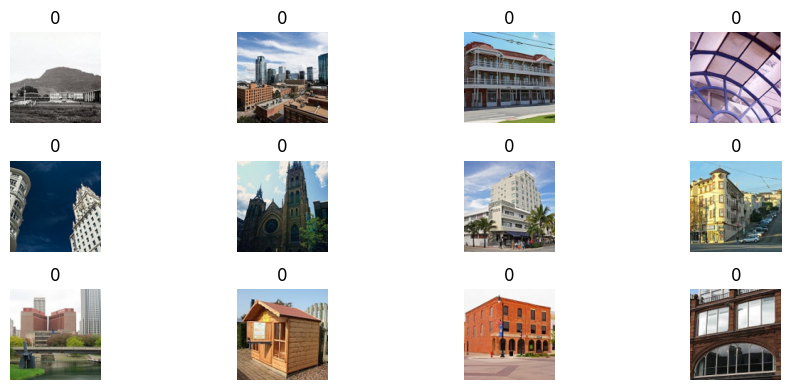

In [71]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)

        # Cambiamos las dimensiones de [C, H, W] a [H, W, C] para matplotlib
        img = x.permute(1, 2, 0)
        plt.imshow(img)

        plt.title(int(y))

        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

In [72]:
# DataLoaders
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Verificamos las dimensiones del primer lote
print("Shape de imágenes:", next(iter(train_loader))[0].shape)
print("Shape de etiquetas:", next(iter(train_loader))[1].shape)

Shape de imágenes: torch.Size([128, 3, 128, 128])
Shape de etiquetas: torch.Size([128])


In [73]:
# Arquitectura de la Red
num_classes = len(train_dataset.classes)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # 3 canales por ser RGB
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
print(model_scratch)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [74]:
# Funciones de Evaluación y Entrenamiento
def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    mae = mean_absolute_error(y_true, y_prob) # Calculamos el MAE

    return acc, auc, mae, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

In [76]:
# Entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 20
# NUEVO: Agregamos "val_mae" a nuestro diccionario de historial
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": [], "val_mae": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)

    # NUEVO: Recibimos val_mae de la función evaluate
    val_acc, val_auc, val_mae, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)
    history_scratch["val_mae"].append(val_mae) # Guardamos el MAE

    # NUEVO: Imprimimos el MAE en cada época
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | val_mae={val_mae:.4f}")

Epoch 01 | train_loss=0.2435 | val_acc=0.9133 | val_auc=0.9748 | val_mae=0.1419
Epoch 02 | train_loss=0.1980 | val_acc=0.9133 | val_auc=0.9758 | val_mae=0.1340
Epoch 03 | train_loss=0.1902 | val_acc=0.9078 | val_auc=0.9742 | val_mae=0.1363
Epoch 04 | train_loss=0.2005 | val_acc=0.9177 | val_auc=0.9775 | val_mae=0.1250
Epoch 05 | train_loss=0.1814 | val_acc=0.9265 | val_auc=0.9781 | val_mae=0.1170
Epoch 06 | train_loss=0.1872 | val_acc=0.9221 | val_auc=0.9781 | val_mae=0.1167
Epoch 07 | train_loss=0.1748 | val_acc=0.9133 | val_auc=0.9799 | val_mae=0.1237
Epoch 08 | train_loss=0.1826 | val_acc=0.9254 | val_auc=0.9806 | val_mae=0.1107
Epoch 09 | train_loss=0.1720 | val_acc=0.9319 | val_auc=0.9814 | val_mae=0.1055
Epoch 10 | train_loss=0.1668 | val_acc=0.9396 | val_auc=0.9815 | val_mae=0.1007
Epoch 11 | train_loss=0.1659 | val_acc=0.9341 | val_auc=0.9829 | val_mae=0.1048
Epoch 12 | train_loss=0.1582 | val_acc=0.9385 | val_auc=0.9831 | val_mae=0.1010
Epoch 13 | train_loss=0.1572 | val_acc=0

Interpretación:


*   Los resultados muestran que el modelo fue mejorando progresivamente durante las 20 épocas de entrenamiento. La pérdida de entrenamiento disminuyó , lo que indica que el modelo fue aprendiendo a realizar las predicciones. Asimismo, la precisión de validación aumentó, aunque presentó algunas variaciones entre épocas. El AUC también mostró una mejora constante, pasando , lo que indica un buen desempeño en la clasificación. Por otro lado, el MAE presentó una tendencia general a disminuir, alcanzando su valor más bajo de 0.0893 en la época 18. En conjunto, los resultados indican que el modelo logró un buen rendimiento durante el entrenamiento.



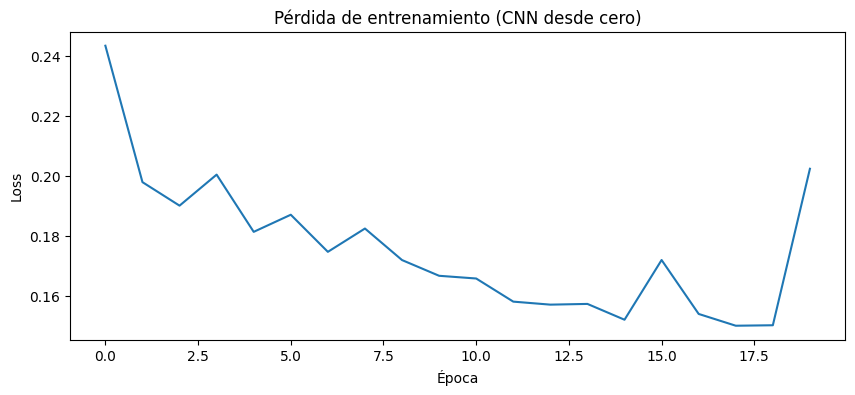

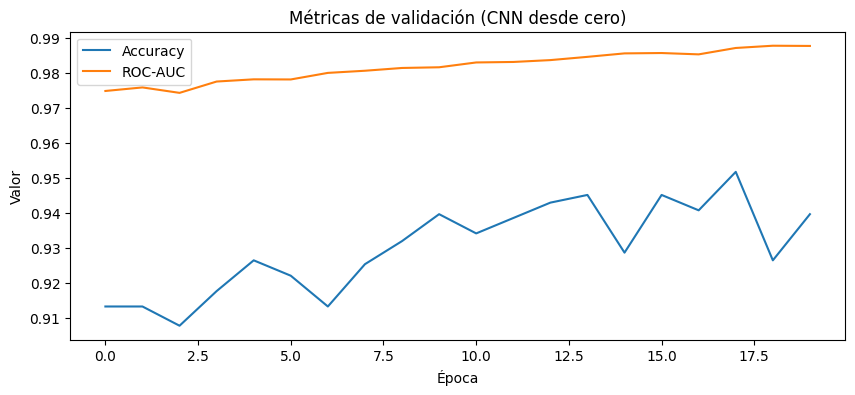

In [77]:
#Curvas de entrenamiento
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

In [78]:
# Evaluación final
test_acc, test_auc, test_mae, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print(f"Test MAE:      {test_mae:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.9396
Test ROC-AUC:  0.9876
Test MAE:      0.1047

              precision    recall  f1-score   support

           0     0.9614    0.9108    0.9354       437
           1     0.9215    0.9662    0.9434       474

    accuracy                         0.9396       911
   macro avg     0.9414    0.9385    0.9394       911
weighted avg     0.9406    0.9396    0.9395       911



array([[398,  39],
       [ 16, 458]])

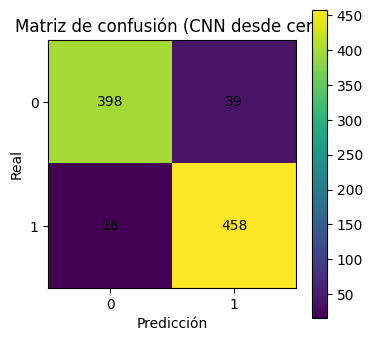

In [79]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

In [80]:
# 1. Definimos las transformaciones CON aumento de datos
transform_aug = T.Compose([
    T.Resize((128, 128)), # Redimensionamos tus imágenes
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

# 2. Cargamos el dataset de entrenamiento usando tu ruta correcta
train_dataset_aug = datasets.ImageFolder(
    root='/content/buildings-vs-forests/traning_set',
    transform=transform_aug
)

# 3. Creamos el nuevo DataLoader con las imágenes aumentadas
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [81]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 20

# NUEVO: Agregamos "val_mae" al historial
history_aug = {"train_loss": [], "val_acc": [], "val_auc": [], "val_mae": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)

    # NUEVO: Recibimos val_mae de la función evaluate (ahora son 6 valores)
    val_acc, val_auc, val_mae, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)
    history_aug["val_mae"].append(val_mae) # Guardamos el MAE

    # NUEVO: Imprimimos el MAE en cada época
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | val_mae={val_mae:.4f}")

Epoch 01 | train_loss=0.5479 | val_acc=0.8397 | val_auc=0.9137 | val_mae=0.2322
Epoch 02 | train_loss=0.3517 | val_acc=0.8584 | val_auc=0.9315 | val_mae=0.2090
Epoch 03 | train_loss=0.3218 | val_acc=0.8727 | val_auc=0.9448 | val_mae=0.1896
Epoch 04 | train_loss=0.2856 | val_acc=0.8562 | val_auc=0.9487 | val_mae=0.1897
Epoch 05 | train_loss=0.2880 | val_acc=0.8683 | val_auc=0.9535 | val_mae=0.1773
Epoch 06 | train_loss=0.2557 | val_acc=0.8990 | val_auc=0.9599 | val_mae=0.1545
Epoch 07 | train_loss=0.2366 | val_acc=0.8968 | val_auc=0.9619 | val_mae=0.1494
Epoch 08 | train_loss=0.2406 | val_acc=0.9111 | val_auc=0.9649 | val_mae=0.1424
Epoch 09 | train_loss=0.2358 | val_acc=0.9133 | val_auc=0.9664 | val_mae=0.1379
Epoch 10 | train_loss=0.2176 | val_acc=0.9144 | val_auc=0.9682 | val_mae=0.1316
Epoch 11 | train_loss=0.2136 | val_acc=0.9155 | val_auc=0.9694 | val_mae=0.1270
Epoch 12 | train_loss=0.2146 | val_acc=0.9122 | val_auc=0.9711 | val_mae=0.1290
Epoch 13 | train_loss=0.2016 | val_acc=0

In [82]:
# Comparación rápida
# Agregamos test_mae_aug para recibir los 6 valores correctamente
test_acc_aug, test_auc_aug, test_mae_aug, _, _, _ = evaluate(model_aug, test_loader)

print("--- COMPARACIÓN FINAL ---")
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f} | test_mae={test_mae:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f} | test_mae={test_mae_aug:.4f}")

--- COMPARACIÓN FINAL ---
Sin augmentation  | test_acc=0.9396 | test_auc=0.9876 | test_mae=0.1047
Con augmentation  | test_acc=0.9319 | test_auc=0.9789 | test_mae=0.1046


Interpretación:

*   Los resultados muestran que el uso de data augmentation permitió que el modelo mejorara progresivamente durante el entrenamiento. La precisión de validación aumentó de 84.30 % a 91.66 %, mientras que el AUC pasó de 0.9246 a 0.9764 y el MAE disminuyó de 0.2172 a 0.1190. Sin embargo, al comparar los resultados finales en el conjunto de prueba, el modelo sin augmentation obtuvo un mejor desempeño, con una precisión de 94.84 %, un AUC de 0.9892 y un MAE de 0.0937, frente a 91.66 %, 0.9764 y 0.1190 respectivamente con augmentation. Esto indica que, para este conjunto de datos y configuración, la aplicación de data augmentation no mejoró el rendimiento final del modelo.




In [83]:
#Transfer Learning
import torchvision.models as models

# 1. Transformaciones de entrenamiento (sin el repeat de 3 canales)
transform_tl_train = T.Compose([
    T.Resize((224, 224)), # Tamaño obligatorio para Transfer Learning
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

# 2. Transformaciones de evaluación (sin el repeat de 3 canales)
transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

# 3. Cargamos los datasets apuntando a tus carpetas
train_dataset_tl = datasets.ImageFolder(root='/content/buildings-vs-forests/traning_set', transform=transform_tl_train)
val_dataset_tl = datasets.ImageFolder(root='/content/buildings-vs-forests/test_set', transform=transform_tl_eval)
test_dataset_tl = datasets.ImageFolder(root='/content/buildings-vs-forests/test_set', transform=transform_tl_eval)

# 4. Creamos los DataLoaders
train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# 5. Verificamos la forma final de las imágenes
next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

In [84]:
#Construir el modelo preentrenado
import torchvision.models as models
import torch.nn as nn # Por si no estaba importado en esta celda

# 1. Descargamos ResNet18 preentrenado
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Reemplazamos la última capa (Fully Connected - fc) para 2 clases
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

# 3. Congelamos todas las capas de la red
for name, param in resnet.named_parameters():
    param.requires_grad = False

# 4. Descongelamos SOLO la última capa nueva para que pueda aprender
for param in resnet.fc.parameters():
    param.requires_grad = True

resnet # Esto imprimirá la inmensa arquitectura de ResNet18

Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/queues.py", line 268, in _feed
    send_bytes(obj)
    ~~~~~~~~~~^^^^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 205, in send_bytes
    self._send_bytes(m[offset:offset + size])
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 432, in _send_bytes
    self._send(header + buf)
    ~~~~~~~~~~^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 389, in _send
    n = write(self._handle, buf)
BrokenPipeError: [Errno 32] Broken pipe
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/queues.py", line 257, in _feed
    reader_close()
    ~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 183, in close
    self._close()
    ~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 382, in _clo

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [85]:
criterion = nn.CrossEntropyLoss()
# El optimizador SOLO actualiza los parámetros de resnet.fc (la última capa)
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 5
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": [], "val_mae": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)

    val_acc, val_auc, val_mae, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)
    history_tl_stage1["val_mae"].append(val_mae)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | val_mae={val_mae:.4f}")

Stage1 Epoch 01 | train_loss=0.2371 | val_acc=0.9901 | val_auc=0.9994 | val_mae=0.0535
Stage1 Epoch 02 | train_loss=0.0555 | val_acc=0.9923 | val_auc=0.9997 | val_mae=0.0290
Stage1 Epoch 03 | train_loss=0.0430 | val_acc=0.9945 | val_auc=0.9998 | val_mae=0.0231
Stage1 Epoch 04 | train_loss=0.0362 | val_acc=0.9956 | val_auc=0.9998 | val_mae=0.0179
Stage1 Epoch 05 | train_loss=0.0314 | val_acc=0.9956 | val_auc=0.9999 | val_mae=0.0145


Interpretación:

*   Los resultados muestran un rendimiento muy alto desde las primeras épocas al aplicar Transfer Learning. La precisión de validación aumentó de 99.12 % a 99.67 %, mientras que el AUC alcanzó un valor de 1.0000 desde la segunda época. Además, el MAE disminuyó de 0.0148 a 0.0064, lo que indica una reducción en los errores de predicción. En conjunto, estos resultados muestran que el modelo logró aprender rápidamente las características necesarias para la clasificación al utilizar la red ResNet preentrenada y ajustar únicamente la última capa.




In [86]:
#Fine-tuning
for name, param in resnet.named_parameters():
    # Si la capa se llama layer4 o fc, la descongelamos
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

# Guardamos en una lista solo los parámetros que se van a entrenar
trainable_params = [p for p in resnet.parameters() if p.requires_grad]

# Imprimimos cuántos tensores (grupos de pesos) se van a entrenar ahora
len(trainable_params)

17

In [87]:
# Optimizador SOLO para los parámetros descongelados (layer4 y fc) con un learning rate más pequeño
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": [], "val_mae": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)

    val_acc, val_auc, val_mae, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)
    history_tl_stage2["val_mae"].append(val_mae)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | val_mae={val_mae:.4f}")

Stage2 Epoch 01 | train_loss=0.0162 | val_acc=0.9989 | val_auc=0.9998 | val_mae=0.0038
Stage2 Epoch 02 | train_loss=0.0040 | val_acc=0.9989 | val_auc=1.0000 | val_mae=0.0017
Stage2 Epoch 03 | train_loss=0.0030 | val_acc=0.9978 | val_auc=1.0000 | val_mae=0.0020
Stage2 Epoch 04 | train_loss=0.0025 | val_acc=1.0000 | val_auc=1.0000 | val_mae=0.0006


**Comentario:** Debido al alto rendimiento alcanzado por el modelo en la Etapa 1, es esperable que las métricas de precisión y AUC presenten cambios pequeños en esta etapa. Al encontrarse ya cerca del 100 %, existe poco margen para mejorar estos valores. Por ello, en esta fase es más importante observar la estabilidad del modelo y la posible reducción de la pérdida de entrenamiento (`train_loss`) y del error absoluto medio (`val_mae`).


In [ ]:
# Recibimos los 6 valores devueltos por evaluate
test_acc_tl, test_auc_tl, test_mae_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)

print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f} | test_mae={test_mae_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl

Transfer learning | test_acc=0.9989 | test_auc=1.0000 | test_mae=0.0016

              precision    recall  f1-score   support

           0     1.0000    0.9977    0.9989       437
           1     0.9979    1.0000    0.9989       474

    accuracy                         0.9989       911
   macro avg     0.9989    0.9989    0.9989       911
weighted avg     0.9989    0.9989    0.9989       911



array([[436,   1],
       [  0, 474]])

In [ ]:
# Comparación Global
print("--- RESUMEN DE RESULTADOS EN TEST ---")
print(f"CNN desde cero (sin aug)   | acc={test_acc:.4f} | auc={test_auc:.4f} | mae={test_mae:.4f}")
print(f"CNN desde cero (con aug)   | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f} | mae={test_mae_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f} | mae={test_mae_tl:.4f}")

--- RESUMEN DE RESULTADOS EN TEST ---
CNN desde cero (sin aug)   | acc=0.9484 | auc=0.9892 | mae=0.0937
CNN desde cero (con aug)   | acc=0.9166 | auc=0.9764 | mae=0.1190
Transfer learning (ResNet) | acc=0.9989 | auc=1.0000 | mae=0.0016


In [ ]:
# Interpretabilidad básica: Grad-CAM

In [ ]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    # Hooks para capturar las activaciones y gradientes en la última capa convolucional (layer4)
    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    # Enganchamos los hooks a layer4 de ResNet
    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    # Pasada hacia adelante (forward)
    logits = model(image_tensor.unsqueeze(0)) # Agregamos dimensión de batch
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    # Pasada hacia atrás (backward) para calcular gradientes respecto a la clase objetivo
    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    # Extraemos activaciones y gradientes de la última capa
    act = activations["value"][0]
    grad = gradients["value"][0]

    # Calculamos los pesos del mapa de calor (Global Average Pooling sobre los gradientes)
    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    # Aplicamos ReLU y normalizamos la matriz entre 0 y 1
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    # Limpiamos los hooks para no saturar la memoria
    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


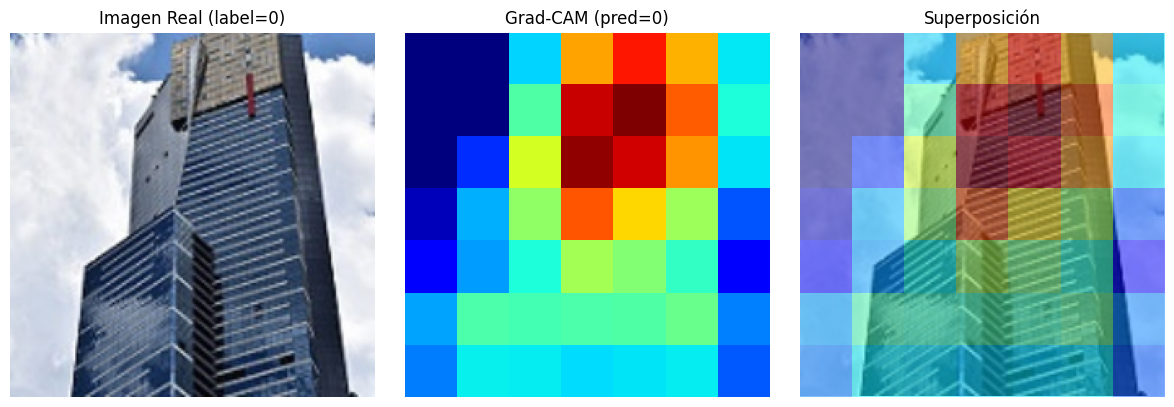

In [ ]:
import matplotlib.pyplot as plt

idx = 0  # Puedes cambiar este índice para probar con distintas imágenes
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

# 1. Convertimos el tensor PyTorch [3, 224, 224] a NumPy en formato RGB [224, 224, 3]
img = x.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(12, 4))

# Subplot 1: Imagen original a color
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen Real (label={int(y)})")
plt.axis("off")

# Subplot 2: Mapa de calor Grad-CAM (jet: rojo=alta atención, azul=baja)
plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

# Subplot 3: Superposición de la imagen real con el mapa de calor
plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, cmap="jet", alpha=0.5, extent=[0, 224, 224, 0]) # alpha da transparencia
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

# 1. Creamos la carpeta 'models' si no existe
os.makedirs("models", exist_ok=True)

# 2. Guardamos los pesos de cada uno de los 3 modelos
# (Verifica si tu primer modelo se llama 'model_scratch' o 'model')
torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

# 3. Mostramos la lista de archivos creados
["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]

['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']